In [2]:
import logging
from dataclasses import dataclass, field

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

def print_dataclass(obj, indent_level=0):
    """
    Recursively prints all fields of a dataclass and its nested dataclasses.
    """
    # Check if the object is a dataclass instance
    if not isinstance(obj, type) or not issubclass(obj, dataclass):
        logger.info(f"{'  ' * indent_level}obj: {obj}")
        for key, value in obj.__dict__.items():
            logger.info(f"{'  ' * indent_level}{key}: {value}")
            # Check if the value is also a dataclass instance
            if isinstance(value, type) or (isinstance(obj, dataclass) and hasattr(obj, '__dataclass_fields__')):
                print_dataclass(value, indent_level + 1)
        return

    for field in obj.__dataclass_fields__.values():
        logger.info(f"{'  ' * indent_level}{field.name}: {getattr(obj, field.name)}")
        value = getattr(obj, field.name)
        # Check if the value is a dataclass instance
        if isinstance(value, type) or (isinstance(obj, dataclass) and hasattr(value, '__dataclass_fields__')):
            print_dataclass(value, indent_level + 1)

# Example usage with nested dataclasses

@dataclass
class Address:
    street: str = "Main Street"
    number: int = 123
    city: str = "New York"

@dataclass
class Person:
    name: str = "John Doe"
    age: int = 30
    address: Address = field(default_factory=Address())

# Create a person instance to print
person = Person()

# Print all attributes and nested dataclasses
logger.info("Printing dataclass details:")
print_dataclass(person)


TypeError: 'Address' object is not callable


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     1804
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:      799

Total number of variables............................:      800
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      800
                     variables with only upper bounds:        0
Total number of equality constraints.................:      402
Total number of inequality c

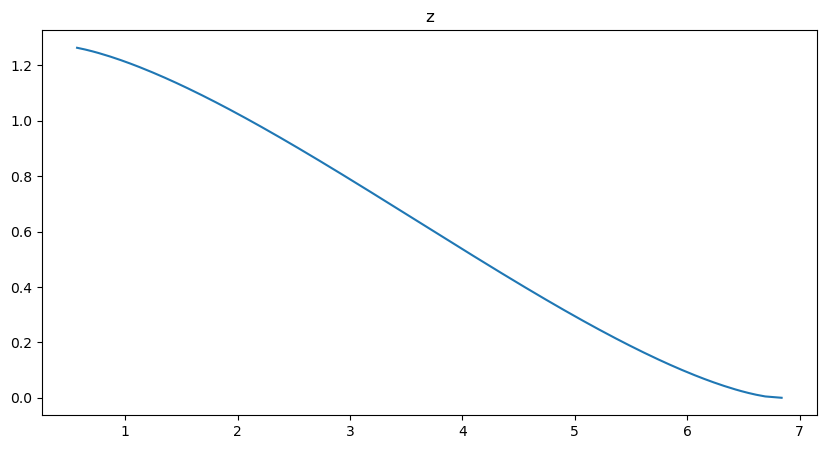

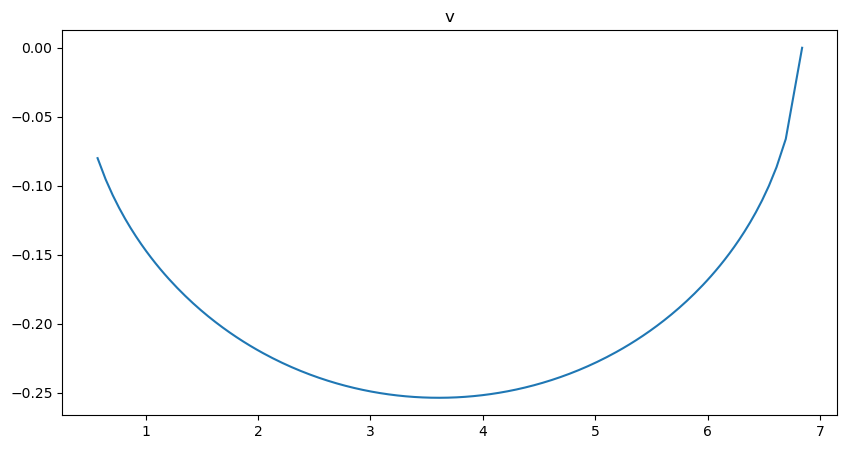

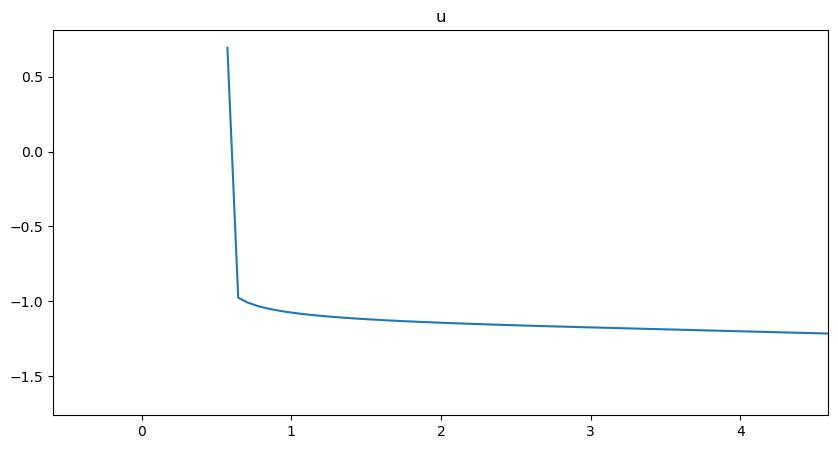

In [3]:
import casadi as ca
import screwCalculus as sc
import numpy as np
import matplotlib.pyplot as plt

m = 1
k = 10
c = 1
g = 9.81

z = ca.SX.sym('s')
v = ca.SX.sym('v')

u = ca.SX.sym('u')

w = ca.SX.sym('w')

dyn_expr = ca.vertcat(v,
                      -1/m*(c + k +u - g))

dyn_fun = ca.Function('dyn', [ca.vertcat(z, v), u], [dyn_expr])

x0 = ca.vertcat(1,1)

W = []
W0 = []
W_lb = []
W_ub = []

g = []

J = 0

N = 200

X_k_1 = x0

for ii in range(0, N):

    X_k = ca.SX.sym(f'X_{ii+1}', 2, 1)
    U_k = ca.SX.sym(f'U_{ii+1}', 1, 1)
    t_k = ca.SX.sym(f't_{ii+1}', 1, 1)

    X_dot = dyn_fun(X_k_1, U_k)

    X_int = sc.RK4_step(X_k_1, U_k, dyn_fun, t_k)

    g.append(X_int - X_k)
    W.append(X_k)
    W.append(U_k)
    W.append(t_k)

    W0.append(ca.vertcat(0,0,5,0.5))
    W_lb.append(ca.vertcat(-100,-100,-50,0))
    W_ub.append(ca.vertcat(100,100,50,5))
    J+= t_k**2 + w*X_dot[1]**2
    X_k_1 = X_k

g.append(X_int - ca.vertcat(0,0))


problem = {'x': ca.vertcat(*W), 'f': J, 'g': ca.vertcat(*g), 'p':w}

solver = ca.nlpsol('S', 'ipopt',problem)
sol = solver(x0 = ca.vertcat(*W0), ubx=  ca.vertcat(*W_ub), lbx= ca.vertcat(*W_lb), lbg= 0, ubg= 0, p = 0.1)

res =  sol['x'].full()

res = np.reshape(res, (4,-1), order='F')
z_ref = res[0,:].reshape(1,-1)
v_ref = res[1,:].reshape(1,-1)
u_ref = res[2,:].reshape(1,-1)
dt = res[3,:].reshape(1,-1)
t = np.cumsum(dt).reshape(1,-1)


plt.figure(figsize=(10, 5)); plt.title('z')
plt.plot(t.T, z_ref.T)
plt.figure(figsize=(10, 5)); plt.title('v')
plt.plot(t.T, v_ref.T)
plt.figure(figsize=(10, 5)); plt.title('u')
plt.plot(t.T, u_ref.T)
# plt.quiver(profile_points[0, :], profile_points[1, :], normals_points[0, :], normals_points[1, :])
plt.axis('equal')
plt.xlim(0, 4)
plt.show()


In [1]:
a = ca.SX.sym('a')



sol_lower = solver(x0 = ca.vertcat(*W0), ubx =  ca.vertcat(*W_ub), lbx= ca.vertcat(*W_lb), lbg = 0, ubg = 0, p = a)


sol_lower = ca.reshape(sol_lower['x'], 4, N)

z_opt = sol_lower[0,:]
v_opt = sol_lower[1,:]
u_opt = sol_lower[2,:]

print(u_opt.shape)
print(u_ref.shape)
J_upper = ca.sum2((z_opt - z_ref)**2)+ca.sum2((v_opt - v_ref)**2)+ca.sum2((u_opt - u_ref)**2)

print(J_upper.shape)
problem_upper = {'x': a, 'f': J_upper}

solver_upper = ca.nlpsol('Su', 'ipopt', problem_upper)

sol = solver_upper(x0 = 1, lbx = 0, ubx = 10)

NameError: name 'ca' is not defined

<>:1: SyntaxWarning: invalid escape sequence '\i'
<>:1: SyntaxWarning: invalid escape sequence '\i'
C:\Users\egrab\AppData\Local\Temp\ipykernel_35396\4019540183.py:1: SyntaxWarning: invalid escape sequence '\i'
  """


Computing synthetic solution with alpha_true = 0.05

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Synthetic solve time: 0.13 s. success=True, tf=1.1279

Starting inverse search (golden-section) over alpha (log10 space from -4 to 1)


C:\Users\egrab\AppData\Local\Temp\ipykernel_35396\4019540183.py:120: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  U_opt[k_i] = float(z_opt[s])


alpha=0.0081251, err=1184.46, tf=0.7283
alpha=0.12308, err=71.395, tf=1.3868
alpha=0.66018, err=283.942, tf=1.9510
alpha=0.043583, err=2.74153, tf=1.0920
alpha=0.022945, err=122.857, tf=0.9371
alpha=0.064793, err=8.01892, tf=1.1982
alpha=0.034111, err=24.0759, tf=1.0304
alpha=0.050711, err=0.0268228, tf=1.1316
alpha=0.055687, err=1.49212, tf=1.1567
alpha=0.04786, err=0.265288, tf=1.1163
alpha=0.052556, err=0.329061, tf=1.1411
alpha=0.049602, err=0.00868782, tf=1.1257
alpha=0.048929, err=0.0642396, tf=1.1221
alpha=0.050023, err=2.79357e-05, tf=1.1280
alpha=0.048929, err=0.0642396, tf=1.1221
alpha=0.050711, err=0.0268228, tf=1.1316
Inverse search finished in 2.26 s. alpha_est=0.0500227, err=2.79357e-05


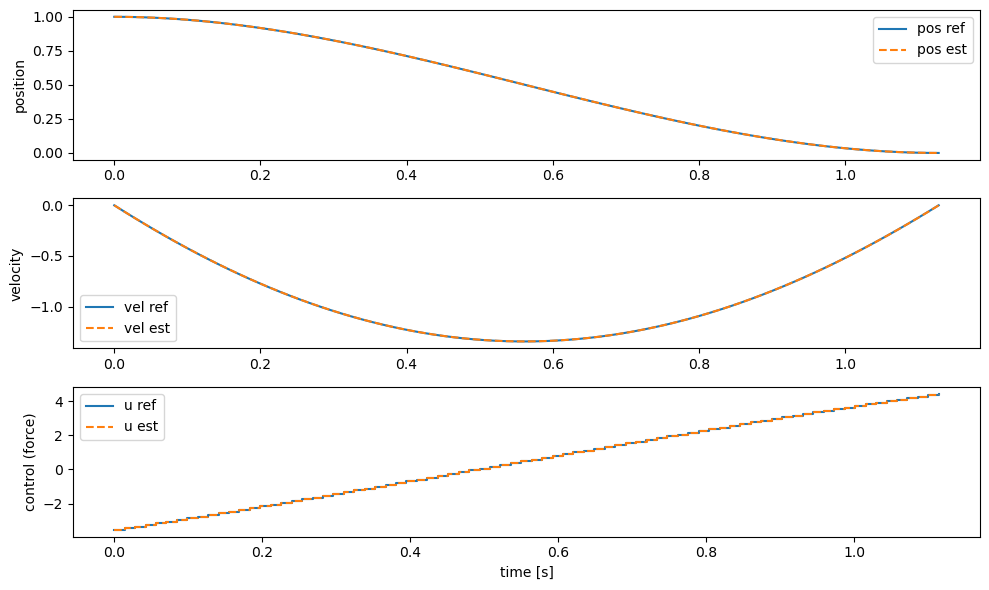


SUMMARY:
True alpha: 0.05
Estimated alpha: 0.0500226973219366
Synthetic tf: 1.1278517537639599
Estimated tf: 1.1279718827612277
Final error metric: 2.7935667223788114e-05


In [1]:
"""
Inverse OCP for spring-mass using CasADi.

- Dynamics: x = [pos, vel], m=1, k=1
    xdot = [v; -k/m * pos + (1/m) * u]

- Inner OCP:
    min  tf + alpha * \int_0^tf u^2 dt
    s.t. x(0)=x0, x(tf)=xT
    discretized with RK4, direct multiple shooting.

- Synthetic solution: generated with alpha_true.
- Inverse: golden-section search (log10(alpha)) to find alpha that minimizes
  sum-of-squared differences between synthetic trajectory and OCP solution.
"""

from casadi import MX, vertcat, nlpsol
import numpy as np
import matplotlib.pyplot as plt
import time

# --- dynamics params ---
m = 1.0
k = 1.0

def spring_dynamics(x, u):
    pos = x[0]
    vel = x[1]
    acc = - (k/m) * pos + (1.0/m) * u
    return vertcat(vel, acc)

def rk4_step(xk, uk, dt):
    k1 = spring_dynamics(xk, uk)
    k2 = spring_dynamics(xk + dt/2 * k1, uk)
    k3 = spring_dynamics(xk + dt/2 * k2, uk)
    k4 = spring_dynamics(xk + dt * k3, uk)
    return xk + dt/6*(k1 + 2*k2 + 2*k3 + k4)

# --- Inner OCP solver ---
def solve_ocp(alpha, x0, xT, N=60, tf_guess=1.0, verbose=False):
    nx = 2
    nu = 1
    nx_total = (N+1)*nx
    nu_total = N*nu
    nz = nx_total + nu_total + 1  # +1 for tf
    z = MX.sym('z', nz)

    def idx_state(k_i):
        start = k_i*nx
        return start, start+nx

    def idx_control(k_i):
        start = nx_total + k_i*nu
        return start, start+nu

    idx_tf = nx_total + nu_total

    cons = []
    tf_z = z[idx_tf]
    cost_z = tf_z
    for k_i in range(N):
        s_i = slice(*idx_state(k_i))
        s_ip1 = slice(*idx_state(k_i+1))
        c_i = slice(*idx_control(k_i))
        xk = z[s_i]
        uk = z[c_i]
        x_next = rk4_step(xk, uk, tf_z/N)
        cons.append(z[s_ip1] - x_next)
        cost_z = cost_z + alpha * (uk.T @ uk) * (tf_z/N)

    cons.append(z[slice(*idx_state(0))] - x0)
    cons.append(z[slice(*idx_state(N))] - xT)

    g = vertcat(*cons)
    nlp = {'x': z, 'f': cost_z, 'g': g}

    # initial guess
    z0 = np.zeros(nz)
    for k_i in range(N+1):
        s = slice(*idx_state(k_i))
        frac = k_i / N
        z0[s] = (1-frac)*np.array(x0).flatten() + frac*np.array(xT).flatten()
    for k_i in range(N):
        s = slice(*idx_control(k_i))
        z0[s] = 0.0
    z0[idx_tf] = tf_guess

    # bounds
    lbz = [-1e20]*nz
    ubz = [1e20]*nz
    for k_i in range(N):
        s = slice(*idx_control(k_i))
        lbz[s] = [-50.0]
        ubz[s] = [50.0]
    lbz[idx_tf] = 1e-3
    ubz[idx_tf] = 20.0

    lbg = [0.0]*g.size1()
    ubg = [0.0]*g.size1()

    opts = {"ipopt.print_level": 0, "print_time": 0}
    solver = nlpsol('solver', 'ipopt', nlp, opts)

    try:
        sol = solver(x0=z0, lbx=lbz, ubx=ubz, lbg=lbg, ubg=ubg)
    except Exception as e:
        if verbose:
            print("Solver failed:", e)
        return {'success': False, 'message': str(e)}

    z_opt = sol['x'].full().flatten()
    tf_opt = float(z_opt[idx_tf])
    X_opt = np.zeros((nx, N+1))
    U_opt = np.zeros(N)
    for k_i in range(N+1):
        s = slice(*idx_state(k_i))
        X_opt[:, k_i] = z_opt[s]
    for k_i in range(N):
        s = slice(*idx_control(k_i))
        U_opt[k_i] = float(z_opt[s])
    return {'success': True, 'tf': tf_opt, 'X': X_opt, 'U': U_opt, 'info': sol}

def trajectory_error(sol_ref, sol_cand):
    Xr = sol_ref['X']
    Ur = sol_ref['U']
    tr = sol_ref['tf']
    Xc = sol_cand['X']
    Uc = sol_cand['U']
    tc = sol_cand['tf']
    err_state = np.sum((Xr - Xc)**2)
    err_control = np.sum((Ur - Uc)**2)
    err_time = (tr - tc)**2
    return float(err_state + err_control + 10.0*err_time)

# --- Setup problem and synthetic data ---
x0 = np.array([1.0, 0.0])
xT = np.array([0.0, 0.0])
alpha_true = 0.05
N = 80

print("Computing synthetic solution with alpha_true =", alpha_true)
t0 = time.time()
sol_ref = solve_ocp(alpha_true, x0, xT, N=N, tf_guess=1.5)
t1 = time.time()
print("Synthetic solve time: %.2f s. success=%s, tf=%.4f" % (t1-t0, sol_ref.get('success',False), sol_ref.get('tf',np.nan)))

def evaluate_alpha_log(log_alpha):
    alpha = float(10**log_alpha)
    sol = solve_ocp(alpha, x0, xT, N=N, tf_guess=sol_ref['tf'])
    if not sol.get('success', False):
        return 1e6
    err = trajectory_error(sol_ref, sol)
    print("alpha=%.5g, err=%.6g, tf=%.4f" % (alpha, err, sol['tf']))
    return err

def golden_section_search(log_a_lo, log_a_hi, tol=1e-2, max_iter=20):
    gr = (np.sqrt(5)-1)/2
    a = log_a_lo
    b = log_a_hi
    c = b - gr*(b-a)
    d = a + gr*(b-a)
    fc = evaluate_alpha_log(c)
    fd = evaluate_alpha_log(d)
    it = 0
    while (b-a) > tol and it < max_iter:
        if fc < fd:
            b = d
            d = c
            fd = fc
            c = b - gr*(b-a)
            fc = evaluate_alpha_log(c)
        else:
            a = c
            c = d
            fc = fd
            d = a + gr*(b-a)
            fd = evaluate_alpha_log(d)
        it += 1
    candidates = [(c, fc), (d, fd), (a, evaluate_alpha_log(a)), (b, evaluate_alpha_log(b))]
    best = min(candidates, key=lambda x: x[1])
    return 10**best[0], best[1]

print("\nStarting inverse search (golden-section) over alpha (log10 space from -4 to 1)")
t0 = time.time()
alpha_est, err_est = golden_section_search(-4.0, 1.0, tol=1e-2, max_iter=12)
t1 = time.time()
print("Inverse search finished in %.2f s. alpha_est=%.6g, err=%.6g" % (t1-t0, alpha_est, err_est))

sol_est = solve_ocp(alpha_est, x0, xT, N=N, tf_guess=sol_ref['tf'])

# Plot results
t_grid_ref = np.linspace(0, sol_ref['tf'], N+1)
t_grid_est = np.linspace(0, sol_est['tf'], N+1)

plt.figure(figsize=(10,6))
plt.subplot(3,1,1)
plt.plot(t_grid_ref, sol_ref['X'][0,:], label='pos ref') 
plt.plot(t_grid_est, sol_est['X'][0,:], label='pos est', linestyle='--')
plt.ylabel('position')
plt.legend()

plt.subplot(3,1,2)
plt.plot(t_grid_ref, sol_ref['X'][1,:], label='vel ref')
plt.plot(t_grid_est, sol_est['X'][1,:], label='vel est', linestyle='--')
plt.ylabel('velocity')
plt.legend()

plt.subplot(3,1,3)
t_u_ref = np.linspace(0, sol_ref['tf']*(1 - 1/(N+1)), N)
t_u_est = np.linspace(0, sol_est['tf']*(1 - 1/(N+1)), N)
plt.step(t_u_ref, sol_ref['U'], where='post', label='u ref')
plt.step(t_u_est, sol_est['U'], where='post', label='u est', linestyle='--')
plt.ylabel('control (force)')
plt.xlabel('time [s]')
plt.legend()

plt.tight_layout()
plt.show()

print("\nSUMMARY:")
print("True alpha:", alpha_true)
print("Estimated alpha:", alpha_est)
print("Synthetic tf:", sol_ref['tf'])
print("Estimated tf:", sol_est['tf'])
print("Final error metric:", err_est)


Solving synthetic (expert) trajectory with p_true = [1.   0.05]
Synthetic solve time: 0.11 s
Reference tf: 1.1279749261232486

Outer iter 0 p_est = [0.5  0.05]
 loss=1.156843e+01, dLdp=[-55.76238243 557.62382195]

Outer iter 1 p_est = [5.55762382e-01 1.00000000e-09]
 loss=4.536988e+04, dLdp=[-2.16778087e+06 -2.37674492e+13]

Outer iter 2 p_est = [1000. 1000.]


C:\Users\egrab\AppData\Local\Temp\ipykernel_35396\2058818669.py:172: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  U[k_i] = z_vec[s:e]


 loss=7.940194e+01, dLdp=[-0.02162417  0.02162417]

Outer iter 3 p_est = [1000.          999.99997838]
 loss=7.940194e+01, dLdp=[-0.02162417  0.02162417]

Outer iter 4 p_est = [1000.          999.99995675]
 loss=7.940194e+01, dLdp=[-0.02162417  0.02162417]

Outer iter 5 p_est = [1000.          999.99993513]
 loss=7.940194e+01, dLdp=[-0.02162417  0.02162417]

Outer iter 6 p_est = [1000.         999.9999135]
 loss=7.940194e+01, dLdp=[-0.02162417  0.02162417]

Outer iter 7 p_est = [1000.          999.99989188]
 loss=7.940194e+01, dLdp=[-0.02162417  0.02162418]

Outer iter 8 p_est = [1000.          999.99987025]
 loss=7.940194e+01, dLdp=[-0.02162417  0.02162418]

Outer iter 9 p_est = [1000.          999.99984863]
 loss=7.940194e+01, dLdp=[-0.02162417  0.02162418]

Outer iter 10 p_est = [1000.          999.99982701]
 loss=7.940194e+01, dLdp=[-0.02162417  0.02162418]

Outer iter 11 p_est = [1000.          999.99980538]
 loss=7.940194e+01, dLdp=[-0.02162417  0.02162418]

Outer iter 12 p_est =

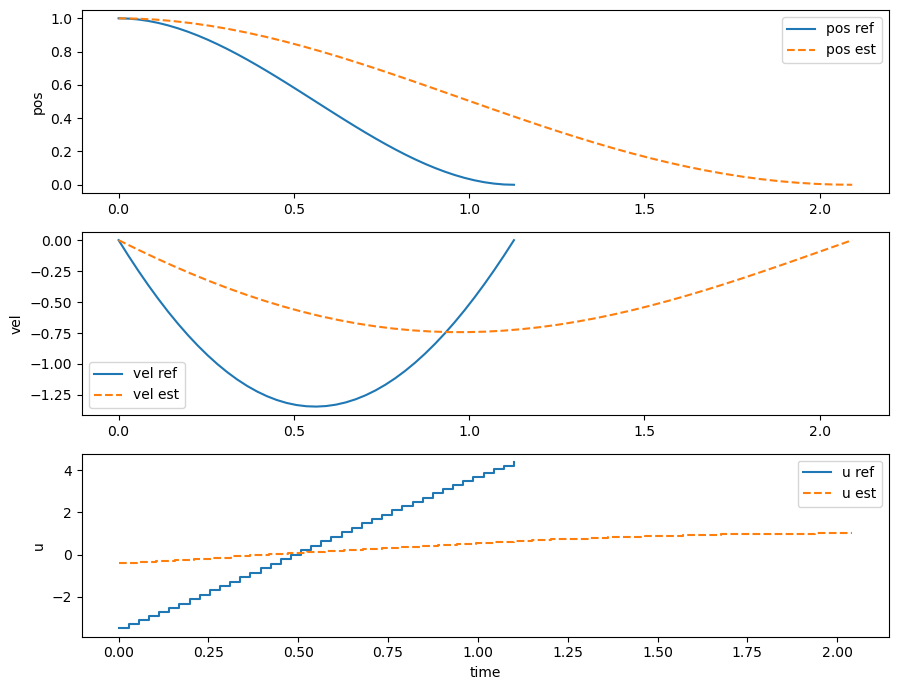


History summary:
{'iter': 0, 'p': array([0.5 , 0.05]), 'loss': 11.568426714045039, 'dLdp': array([-55.76238243, 557.62382195])}
{'iter': 1, 'p': array([5.55762382e-01, 1.00000000e-09]), 'loss': 45369.881506629215, 'dLdp': array([-2.16778087e+06, -2.37674492e+13])}
{'iter': 2, 'p': array([1000., 1000.]), 'loss': 79.40194062641152, 'dLdp': array([-0.02162417,  0.02162417])}
{'iter': 3, 'p': array([1000.        ,  999.99997838]), 'loss': 79.40193958155885, 'dLdp': array([-0.02162417,  0.02162417])}
{'iter': 4, 'p': array([1000.        ,  999.99995675]), 'loss': 79.401939113954, 'dLdp': array([-0.02162417,  0.02162417])}
{'iter': 5, 'p': array([1000.        ,  999.99993513]), 'loss': 79.4019386463491, 'dLdp': array([-0.02162417,  0.02162417])}
{'iter': 6, 'p': array([1000.       ,  999.9999135]), 'loss': 79.40193817874417, 'dLdp': array([-0.02162417,  0.02162417])}
{'iter': 7, 'p': array([1000.        ,  999.99989188]), 'loss': 79.40193771113923, 'dLdp': array([-0.02162417,  0.02162418])}

In [12]:
"""
Corrected inverse OCP using KKT sensitivities (direct multiple shooting).
Fixed free-variable issue by declaring parameters in the NLP ('p' entry).
"""

import numpy as np
import matplotlib.pyplot as plt
import time
from casadi import MX, vertcat, jacobian, nlpsol, Function, inv, DM

# --------- problem definition ----------
m = 1.0
k = 1.0

def spring_dynamics(x, u):
    pos = x[0]
    vel = x[1]
    acc = - (k/m) * pos + (1.0/m) * u
    return vertcat(vel, acc)

def rk4_step(xk, uk, dt):
    k1 = spring_dynamics(xk, uk)
    k2 = spring_dynamics(xk + dt/2 * k1, uk)
    k3 = spring_dynamics(xk + dt/2 * k2, uk)
    k4 = spring_dynamics(xk + dt * k3, uk)
    return xk + dt/6*(k1 + 2*k2 + 2*k3 + k4)

# --------- discretization ----------
N = 40       # shooting intervals (reduce for speed)
nx = 2
nu = 1

nx_total = (N+1)*nx
nu_total = N*nu
nz = nx_total + nu_total + 1  # +1 for tf

def idx_state(k):
    return k*nx, k*nx + nx

def idx_control(k):
    return nx_total + k*nu, nx_total + k*nu + nu

idx_tf = nx_total + nu_total

# --------- symbolic variables ----------
z = MX.sym('z', nz)            # decision variables
p = MX.sym('p', 2)             # parameters: [w_time, w_ctrl]
x0_param = MX.sym('x0', nx)    # initial state (parameter)
xT_param = MX.sym('xT', nx)    # target state (parameter)

# ---------- build cost and constraints (symbolic) ----------
g_list = []
tf_sym = z[idx_tf]
f_sym = p[0] * tf_sym  # w_time * tf

for k_i in range(N):
    s_i, e_i = idx_state(k_i)
    s_ip1, e_ip1 = idx_state(k_i+1)
    c_i, c_e = idx_control(k_i)
    xk = z[s_i:e_i]
    uk = z[c_i:c_e]
    x_next = z[s_ip1:e_ip1]
    x_next_pred = rk4_step(xk, uk, tf_sym / N)
    g_list.append(x_next - x_next_pred)
    f_sym = f_sym + p[1] * (uk.T @ uk) * (tf_sym / N)

# initial and terminal constraints
g_list.append(z[idx_state(0)[0]:idx_state(0)[1]] - x0_param)
g_list.append(z[idx_state(N)[0]:idx_state(N)[1]] - xT_param)

g_sym = vertcat(*g_list)             # constraints stacked
n_lambda = int(g_sym.size1())        # number of multipliers

# ---------- KKT / implicit diff ----------
lam = MX.sym('lam', n_lambda)        # multipliers (size matches g_sym)
Lz = jacobian(f_sym, z).T + jacobian(g_sym, z).T @ lam
F = vertcat(Lz, g_sym)               # KKT residuals
y = vertcat(z, lam)

A = jacobian(F, y)
B = jacobian(F, p)

# dy/dp = -A^{-1} B  -> dz/dp = first nz rows
# (Warning: may be expensive / ill-conditioned for big problems)
dydp = - inv(A) @ B
dzdp = dydp[0:nz, :]

# Create CasADi functions for sensitivities
dzdp_fun = Function('dzdp_fun', [y, p, x0_param, xT_param], [dzdp])
A_fun = Function('A_fun', [y, p, x0_param, xT_param], [A])
B_fun = Function('B_fun', [y, p, x0_param, xT_param], [B])
F_fun = Function('F_fun', [y, p, x0_param, xT_param], [F])

# ---------- build parametric NLP (declare parameters explicitly) ----------
# nlp parameters vector (stacked)
p_full = vertcat(p, x0_param, xT_param)
nlp = {'x': z, 'p': p_full, 'f': f_sym, 'g': g_sym}

opts = {"ipopt.print_level": 0, "print_time": 0}
solver = nlpsol('solver', 'ipopt', nlp, opts)   # solver created once

# ---------- helper: solve inner nlp ----------
def solve_inner_nlp(p_num, x0_num, xT_num, z0_guess=None, verbose=False):
    # initial guess
    if z0_guess is None:
        z0 = np.zeros(nz)
        for k_i in range(N+1):
            s,e = idx_state(k_i)
            frac = k_i / N
            z0[s:e] = (1-frac)*x0_num + frac*xT_num
        for k_i in range(N):
            s,e = idx_control(k_i)
            z0[s:e] = 0.0
        z0[idx_tf] = 1.0
    else:
        z0 = z0_guess.copy()

    # bounds
    lbz = [-1e20]*nz
    ubz = [1e20]*nz
    for k_i in range(N):
        s,e = idx_control(k_i)
        lbz[s:e] = [-50.0]
        ubz[s:e] = [50.0]
    lbz[idx_tf] = 1e-3
    ubz[idx_tf] = 20.0

    lbg = [0.0]*n_lambda
    ubg = [0.0]*n_lambda

    # build parameter vector for solver: [p; x0; xT]
    pvec = np.concatenate([np.array(p_num).reshape(-1), np.array(x0_num).reshape(-1), np.array(xT_num).reshape(-1)])
    try:
        sol = solver(x0=z0, p=pvec, lbx=lbz, ubx=ubz, lbg=lbg, ubg=ubg)
    except Exception as e:
        if verbose:
            print("nlpsol failed:", e)
        return {'success': False, 'message': str(e)}
    z_opt = np.array(sol['x']).flatten()
    lam_g = None
    if 'lam_g' in sol:
        lam_g = np.array(sol['lam_g']).flatten()
    else:
        # If not returned, set zeros (less ideal). You can try solver options to return multipliers.
        lam_g = np.zeros(n_lambda)
        if verbose:
            print("Warning: solver did not return 'lam_g' multipliers; using zeros.")
    return {'success': True, 'z': z_opt, 'lam_g': lam_g, 'sol': sol}

# ---------- create synthetic (expert) trajectory ----------
x0_num = np.array([1.0, 0.0])
xT_num = np.array([0.0, 0.0])
p_true = np.array([1.0, 0.05])   # true weights

print("Solving synthetic (expert) trajectory with p_true =", p_true)
t0 = time.time()
res_ref = solve_inner_nlp(p_true, x0_num, xT_num, verbose=True)
if not res_ref['success']:
    raise RuntimeError("Failed to compute reference solution.")
t1 = time.time()
print("Synthetic solve time: %.2f s" % (t1 - t0))
z_ref = res_ref['z']

def unpack_z(z_vec):
    X = np.zeros((nx, N+1))
    U = np.zeros(N)
    for k_i in range(N+1):
        s,e = idx_state(k_i)
        X[:, k_i] = z_vec[s:e]
    for k_i in range(N):
        s,e = idx_control(k_i)
        U[k_i] = z_vec[s:e]
    tf_val = z_vec[idx_tf]
    return X, U, tf_val

X_ref, U_ref, tf_ref = unpack_z(z_ref)
print("Reference tf:", tf_ref)

# ---------- outer loop: estimate p via sensitivity-based gradient steps ----------
p_est = np.array([0.5, 0.05])   # initial guess
max_outer_iters = 500
alpha_lr = 1e-3 # step size (tune)
tol_p = 1e-8
z_guess = None

history = []
for it in range(max_outer_iters):
    print("\nOuter iter", it, "p_est =", p_est)
    res = solve_inner_nlp(p_est, x0_num, xT_num, z0_guess=z_guess, verbose=False)
    if not res['success']:
        print("Inner solver failed at outer iter", it)
        break
    z_opt = res['z']
    lam_g = res['lam_g']
    z_guess = z_opt  # warm start
    y_val = np.concatenate([z_opt, lam_g])

    # evaluate dz/dp
    try:
        dzdp_val = np.array(dzdp_fun(y_val, p_est, x0_num, xT_num)).squeeze()
    except Exception as e:
        print("Failed to evaluate dz/dp:", e)
        break

    # outer loss (0.5*||z - z_ref||^2)
    diff = z_opt - z_ref
    loss = 0.5 * float(diff @ diff)
    dLdp = diff @ dzdp_val   # shape (2,)
    print(" loss=%.6e, dLdp=%s" % (loss, dLdp))
    history.append({'iter': it, 'p': p_est.copy(), 'loss': loss, 'dLdp': dLdp.copy()})

    # gradient step
    p_new = p_est - alpha_lr * dLdp
    p_new = np.maximum(p_new, 1e-9)   # ensure positive weights
    p_new = np.minimum(p_new, 1e3)

    if np.linalg.norm(p_new - p_est) < tol_p:
        print("Small parameter update -> stopping.")
        p_est = p_new
        break
    p_est = p_new

print("\nEstimated p:", p_est, " True p:", p_true)

# final solve with estimated p and plot comparison
res_est = solve_inner_nlp(p_est, x0_num, xT_num, z0_guess=z_guess)
z_est = res_est['z']
X_est, U_est, tf_est = unpack_z(z_est)

t_grid_ref = np.linspace(0, tf_ref, N+1)
t_grid_est = np.linspace(0, tf_est, N+1)
t_u_ref = np.linspace(0, tf_ref*(1-1/(N+1)), N)
t_u_est = np.linspace(0, tf_est*(1-1/(N+1)), N)

plt.figure(figsize=(9,7))
plt.subplot(3,1,1)
plt.plot(t_grid_ref, X_ref[0,:], label='pos ref')
plt.plot(t_grid_est, X_est[0,:], '--', label='pos est')
plt.legend(); plt.ylabel('pos')

plt.subplot(3,1,2)
plt.plot(t_grid_ref, X_ref[1,:], label='vel ref')
plt.plot(t_grid_est, X_est[1,:], '--', label='vel est')
plt.legend(); plt.ylabel('vel')

plt.subplot(3,1,3)
plt.step(t_u_ref, U_ref, where='post', label='u ref')
plt.step(t_u_est, U_est, where='post', label='u est', linestyle='--')
plt.legend(); plt.ylabel('u'); plt.xlabel('time')

plt.tight_layout()
plt.show()

print("\nHistory summary:")
for h in history:
    print(h)



In [23]:
import casadi as ca
import time


def build_problem(N=1000, use_params=False):
    """
    Build a nonlinear constrained problem:
    minimize sum_i (x[i] - target[i])^2
    subject to nonlinear constraints:
        sum(sin(x[i])) == N/10
        prod(cos(x[i%10])) >= 0.1
    """
    targets = list(range(1, N + 1))
    half = N // 2

    if use_params:
        # 500 decision variables, 500 parameters
        x = ca.MX.sym("x", half)
        p = ca.MX.sym("p", half)

        exprs = []
        for i in range(N):
            if i < half:
                exprs.append((x[i] - targets[i]) ** 2)
            else:
                exprs.append((p[i - half] - targets[i]) ** 2)
        f = sum(exprs)

        # nonlinear constraints using both x and p
        g1 = ca.sum1(ca.sin(ca.vertcat(x, p))) - N / 10
        v = ca.cos(x[0:10])
        g2 = 1
        for ii in range(0, v.shape[0]):
            g2 *= v[ii]
        g2 -= 0.1

        nlp = {"x": x, "f": f, "g": ca.vertcat(g1, g2), "p": p}
        solver = ca.nlpsol("solver", "ipopt", nlp,
                           {"ipopt.print_level": 0, "print_time": 0})

        lbx = [-ca.inf] * half
        ubx = [ ca.inf] * half
        lbg = [0, 0]
        ubg = [0, ca.inf]
        return solver, lbx, ubx, lbg, ubg, targets[half:]

    else:
        # 1000 decision variables, 500 locked
        x = ca.MX.sym("x", N)
        exprs = [(x[i] - targets[i]) ** 2 for i in range(N)]
        f = sum(exprs)

        # nonlinear constraints with x only
        g2 = 1
        g1 = ca.sum1(ca.sin(x)) - N / 10
        v = ca.cos(x[0:10])
        for ii in range(0, v.shape[0]):
            g2 *= v[ii]
        g2 -= 0.1

        nlp = {"x": x, "f": f, "g": ca.vertcat(g1, g2)}
        solver = ca.nlpsol("solver", "ipopt", nlp,
                           {"ipopt.print_level": 0, "print_time": 0})

        lbx = [-ca.inf] * N
        ubx = [ ca.inf] * N
        for i in range(N // 2, N):
            lbx[i] = targets[i]
            ubx[i] = targets[i]

        lbg = [0, 0]
        ubg = [0, ca.inf]
        return solver, lbx, ubx, lbg, ubg, None


def benchmark(N=1000):
    results = {}

    # Case 1: half parameters
    solver, lbx, ubx, lbg, ubg, pvals = build_problem(N, use_params=True)
    t0 = time.time()
    sol = solver(lbx=lbx, ubx=ubx, lbg=lbg, ubg=ubg,
                 x0=[0] * (N // 2), p=pvals)
    results["half_params"] = time.time() - t0

    # Case 2: half locked
    solver, lbx, ubx, lbg, ubg, _ = build_problem(N, use_params=False)
    t0 = time.time()
    sol = solver(lbx=lbx, ubx=ubx, lbg=lbg, ubg=ubg,
                 x0=[0] * N)
    results["half_locked"] = time.time() - t0

    return results


if __name__ == "__main__":
    for N in [200, 500, 1000, 5000]:
        print(f"\n=== Benchmark with N={N} variables ===")
        res = benchmark(N)
        for k, v in res.items():
            print(f"{k:12s}: {v:.6f} s")



=== Benchmark with N=200 variables ===
half_params : 0.227968 s
half_locked : 0.241588 s

=== Benchmark with N=500 variables ===
half_params : 2.993030 s
half_locked : 3.595459 s

=== Benchmark with N=1000 variables ===
half_params : 0.185214 s
half_locked : 0.103016 s

=== Benchmark with N=5000 variables ===
half_params : 1.232090 s
half_locked : 1.147362 s
